# Inference Quick Start

This notebook shows how to run Migas-1.5 on **your own data** end-to-end:

1. **Load time series data** — load values from a CSV file (columns: `t`, `y_t`, `split`).
2. **Prepare a text summary** — learn the two-part `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` format the model expects. A sample summary is provided so the notebook runs out of the box; an optional section shows how to auto-generate one with an LLM.
3. **Forecast** — compare Chronos-2 (text-free baseline) against Migas-1.5 (text-conditioned).
4. **Counterfactual exploration** — rewrite the predictive signals and watch the forecast shift, demonstrating the text-conditioned time series forecasting.

**Requirements:** Install the package from the repo root (`uv sync`). Section 3 (LLM summary generation) optionally requires an OpenAI or Anthropic API key.

**See also:** [Counterfactual Scenarios](migas-1.5-counterfactual-scenarios.ipynb) · [Batch Inference](migas-1.5-batch-inference.ipynb) · [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

## User Configuration

**Edit the cell below before running anything else.** All parameters you are likely to
want to change are collected here — you should not need to touch anything else in the
notebook for a basic run.

| Parameter | What it controls | Typical values |
|-----------|-----------------|----------------|
| `DATA_PATH` | CSV with columns `t`, `y_t`, `split` (`"context"` / `"ground_truth"`) | Relative to this notebook |
| `SUMMARY_PATH` | Pre-computed summary text file | Relative to this notebook |
| `SERIES_NAME` | Human-readable name for the series (used in plot labels and LLM prompts) | Any descriptive string |
| `SEQ_LEN` | Steps of history fed to the model (context window) | shorter = clearer local trends |
| `PRED_LEN` | Number of steps to forecast | `8` – `64` |
| `LLM_PROVIDER` | LLM used to auto-generate the text summary in Section 3 | `"anthropic"` (recommended) or `"openai"` |
| `LLM_API_KEY` | API key for the LLM provider — **required only for Section 3** | Set via env var `ANTHROPIC_API_KEY` / `OPENAI_API_KEY` |

**Also check:**
- **Section 2** — replace the loaded `summary` with one that matches your series and date window.
- **Section 5** — edit `bullish_predictive` / `bearish_predictive` to craft your own counterfactual narratives.

In [64]:
import os

# ── USER CONFIGURATION — edit here, then run the notebook top-to-bottom ──────

DATA_PATH    = "../data/nflx_sample.csv"           # <-- CHANGE ME: CSV with columns t, y_t, split
SUMMARY_PATH = "../data/nflx_sample_summary.txt"   # <-- CHANGE ME: pre-computed summary text file
SERIES_NAME  = "Netflix"                  # <-- CHANGE ME: human-readable name for the series
SEQ_LEN      = 64                                            # <-- CHANGE ME: context window in steps
PRED_LEN     = 16                                            # <-- CHANGE ME: forecast horizon in steps
LLM_PROVIDER = "anthropic"                                   # <-- CHANGE ME: "anthropic" (recommended) | "openai"
LLM_API_KEY  = os.getenv({"anthropic": "ANTHROPIC_API_KEY", "openai": "OPENAI_API_KEY"}[LLM_PROVIDER])
# LLM_API_KEY is optional — only needed for Section 3 (LLM summary generation)

# ─────────────────────────────────────────────────────────────────────────────

In [65]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import sys
from textwrap import dedent

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from migaseval import MigasPipeline
from migaseval.model.inference_utils import evaluate_chronos_quantiles

sys.path.insert(0, "..")
from scripts.counterfactual_utils import (composite_trend_score,
                                          extract_factual, extract_predictive,
                                          linear_slope, splice_summary)
from scripts.summary_utils import call_llm
from scripts.plotting_utils import (COLORS, _draw_forecast_region,
                                    apply_migas_style, plot_forecast_single)
from scripts.summary_utils import generate_summary

apply_migas_style()

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained(
    "Synthefy/migas-1.5", device=device, text_embedder_device=device
)
print(f"Using device: {device}")

Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cpu


## 1. Load Time Series Data

Below we load values from a CSV file. The CSV must have at least two columns:

| Column | Description |
|--------|-------------|
| `t` | Date string (`YYYY-MM-DD`) |
| `y_t` | Numeric value |

The last `SEQ_LEN + PRED_LEN` rows are taken: the first `SEQ_LEN` rows form the
**context window** fed to the model; the remaining `PRED_LEN` rows are held out as
**ground truth** so we can measure forecast accuracy.

You can swap `DATA_PATH` for any CSV that follows this format.

In [66]:
raw = pd.read_csv(DATA_PATH)
raw["t"] = pd.to_datetime(raw["t"]).dt.strftime("%Y-%m-%d")

# Take the last SEQ_LEN + PRED_LEN rows so the window is always exactly the right size
full = raw[["t", "y_t"]].iloc[-(SEQ_LEN + PRED_LEN):].reset_index(drop=True)

# Context window fed to the model
series = full.iloc[:SEQ_LEN][["t", "y_t"]].copy().reset_index(drop=True)
series["text"] = ""

# Ground truth for the forecast horizon
gt_vals = full.iloc[SEQ_LEN:]["y_t"].values.astype(np.float32)

print(
    f"Context window : {SEQ_LEN} steps  ({series['t'].iloc[0]} → {series['t'].iloc[-1]})"
)
print(
    f"Forecast window: {PRED_LEN} steps  ({full['t'].iloc[SEQ_LEN]} → {full['t'].iloc[-1]})"
)
print(f"Context value range : {series['y_t'].min():.4f} – {series['y_t'].max():.4f}")
series.tail()

Context window : 64 steps  (2019-02-12 → 2019-05-14)
Forecast window: 16 steps  (2019-05-15 → 2019-06-06)
Context value range : 345.2600 – 385.0300


,t,y_t,text
59,2019-05-08,364.369995,
60,2019-05-09,362.750000,
61,2019-05-10,361.040009,
62,2019-05-13,345.260010,
63,2019-05-14,345.609985,


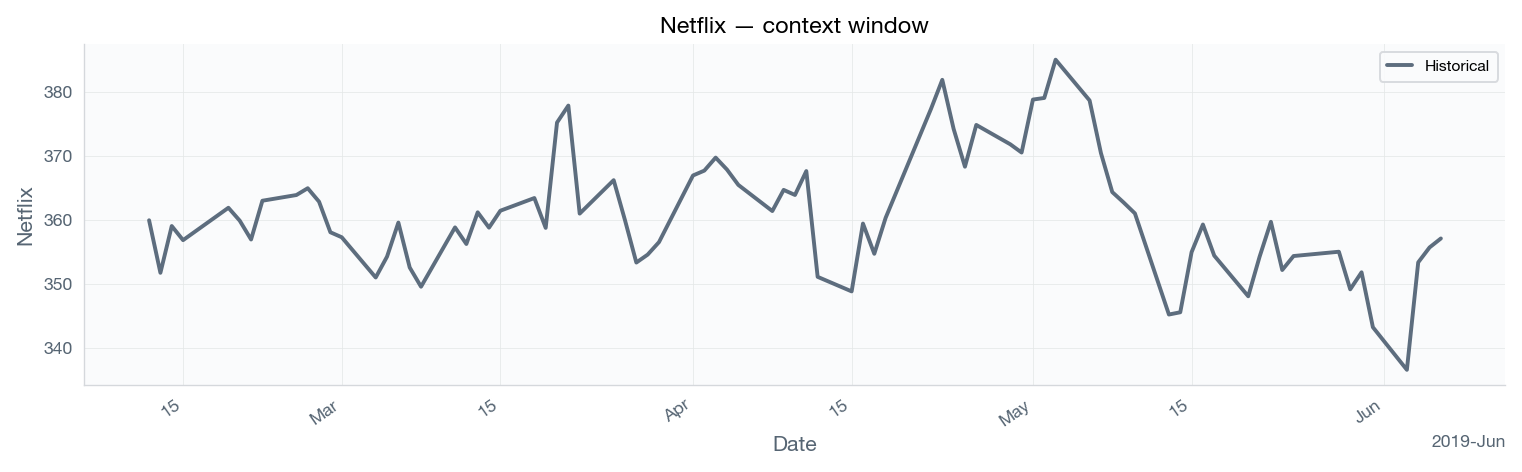

In [67]:
# Quick look at the context window before running the model
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    pd.to_datetime(full["t"].values),
    full["y_t"].values,
    color=COLORS["historical"],
    lw=2.0,
    solid_capstyle="round",
    label="Historical",
)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(35)
    lbl.set_ha("right")
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(SERIES_NAME, color="#566573")
ax.set_title(f"{SERIES_NAME} — context window")
ax.legend(fontsize=8, handlelength=1.6)
fig.tight_layout(pad=1.2)
plt.show()

## 2. Understanding the Summary Format

Migas-1.5 accepts a **text summary** alongside the time series. The summary must follow a two-part structure:

| Section | Purpose |
|---------|---------|
| `FACTUAL SUMMARY` | What already happened — observed trends, price action, key events, macro drivers |
| `PREDICTIVE SIGNALS` | Forward-looking interpretation — analyst outlook, catalysts, risks |

This is the format produced by Migas-1.5's internal `ContextSummarizer` (which calls an LLM over per-timestep text). The model was trained to condition on this structure, so deviating significantly from it will reduce text impact.

Below is a pre-computed summary for the energy series loaded above. **To generate a fresh one from real headlines, see Section 3.**

In [68]:
# Load pre-computed summary — illustrates the required format.
# Replace with a summary that matches your series and date window,  # <-- CHANGE ME
# or let Section 3 generate one automatically with an LLM.
with open(SUMMARY_PATH) as f:
    summary = f.read().strip()

news_digest = ""

print(summary)

**FACTUAL SUMMARY:**  
Recent timesteps show a mixed landscape for Netflix: analyst sentiment oscillates between bullish (e.g., Stifel’s $400 target, Piper Jaffray’s $440 overweight) and cautious (e.g., Wedbush’s $183 under‑perform, Imperial Capital’s reduced $458 target) as competition from Disney+, Apple, and ad‑supported rivals intensifies. Subscriber growth has begun to decelerate, prompting discussion of an ad‑supported tier and concerns over rising content costs, while strategic moves such as the StoryBots acquisition and a new New York production hub aim to broaden the audience base.

**PREDICTIVE SIGNALS:**  
Analysts expect Netflix to lean on new revenue streams—particularly an ad‑supported tier that could add $1‑$2 bn annually—and to leverage its expanded kids’ and international content to sustain subscriber additions despite competitive pressure. The convergence of modest price‑target revisions, ongoing content‑spend, and heightened investor interest (e.g., strong options ac

## 3. (Optional) Generate a Summary with an LLM

A good summary requires context about the series over the full context window.
This section generates a `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` using an LLM:

- **Anthropic (recommended)** — Claude uses its built-in web search tool to autonomously
  find news and market events for the exact date range, then summarizes them. No extra API
  key required beyond your Anthropic key.
- **OpenAI / vLLM** — generates a summary from value data only (no web search available).

**Required environment variables:**
- `ANTHROPIC_API_KEY` or `OPENAI_API_KEY` — required to call the LLM.

If no LLM key is found the section is skipped and the pre-computed summary is kept.

In [69]:
# LLM_PROVIDER is set in the User Configuration cell at the top of the notebook.
LLM_BASE_URL = os.getenv("VLLM_BASE_URL")   # None → use provider default
LLM_MODEL    = os.getenv("VLLM_MODEL")       # None → use provider default

In [70]:
if not LLM_API_KEY:
    print("Skipping LLM summary generation — no LLM API key found.")
    print("Using the pre-computed summary.")
else:
    summary, news_digest = generate_summary(
        SERIES_NAME, series, PRED_LEN,
        llm_provider=LLM_PROVIDER,
        llm_api_key=LLM_API_KEY,
        llm_base_url=LLM_BASE_URL,
        llm_model=LLM_MODEL,
        return_news=True,
    )
    if news_digest:
        print("\n" + "=" * 60)
        print("NEWS DIGEST (raw web search findings)")
        print("=" * 60)
        print(news_digest)

Using Claude web search for Netflix (2019-02-12 → 2019-05-14) …

Generated summary:

FACTUAL SUMMARY:
Netflix stock traded in a generally constructive range of roughly $349–$385 from mid-February through early May 2019, buoyed by the company's January price hike (13–18%, its largest ever), a record Q1 2019 subscriber addition of 9.6 million, and broadly bullish analyst sentiment that largely dismissed competitive threats from the upcoming Disney+ and Apple TV+ launches. The stock hit a period high near $385 on May 3 before sharply reversing as President Trump's May 5 tweet threatening to raise China tariffs from 10% to 25% on $200 billion in Chinese goods triggered a broad risk-off selloff in Nasdaq and growth stocks, sending NFLX down roughly 10% in less than two weeks to close near $345–$346 by May 14. Company-specific headwinds also included a notably weak Q2 EPS guide ($0.55 vs. $0.99 expected), a widened 2019 free cash flow deficit forecast of -$3.5 billion, and lingering question

## 4. Forecast: Chronos-2 Baseline vs. Migas-1.5

We run two forecasts on the same numerical context:

- **Chronos-2** — Migas's own internal Chronos backbone, before text fusion.
- **Migas-1.5** — same Chronos base, fused with the text summary above.

Both share the **exact same normalization path and Chronos call** — so the gap
between the two lines is the pure text conditioning effect.

**If the pre-written summary doesn't match your actual data window**, text can
steer the forecast in the wrong direction (Migas MAPE > Chronos MAPE). Run
Section 3 to generate a window-aligned summary and close that gap.

In [71]:
context_vals = series["y_t"].values.astype(np.float32)
context_tensor = (
    torch.tensor(context_vals, dtype=torch.float32)
    .unsqueeze(0)
    .unsqueeze(-1)
    .to(device)  # (1, SEQ_LEN, 1)
)

# Migas-1.5 + its internal Chronos-2 baseline — same normalization path, one call
migas_fc, chronos_fc_raw = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN,
    summaries=[summary], return_univariate=True,
)
chronos_fc = chronos_fc_raw

# Chronos-2 uncertainty band (10th / 90th percentile) — standalone call for shading only
chronos_q = evaluate_chronos_quantiles(
    context_tensor, PRED_LEN, device=device, chronos_device=device,
    quantile_levels=[0.1, 0.9],
)
chronos_lo = chronos_q["0.1"][0]
chronos_hi = chronos_q["0.9"][0]

print(
    f"Chronos-2 forecast : {chronos_fc.shape}  range [{chronos_fc.min():.4f}, {chronos_fc.max():.4f}]"
    f"  (80% band: [{chronos_lo.min():.4f}, {chronos_hi.max():.4f}])"
)
print(
    f"Migas-1.5 forecast : {migas_fc.shape}  range [{migas_fc.min():.4f}, {migas_fc.max():.4f}]"
)
print("Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect.")

Chronos-2 forecast : (16,)  range [348.6102, 364.8956]  (80% band: [341.1871, 383.3122])
Migas-1.5 forecast : (16,)  range [347.0667, 356.0967]
Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect.


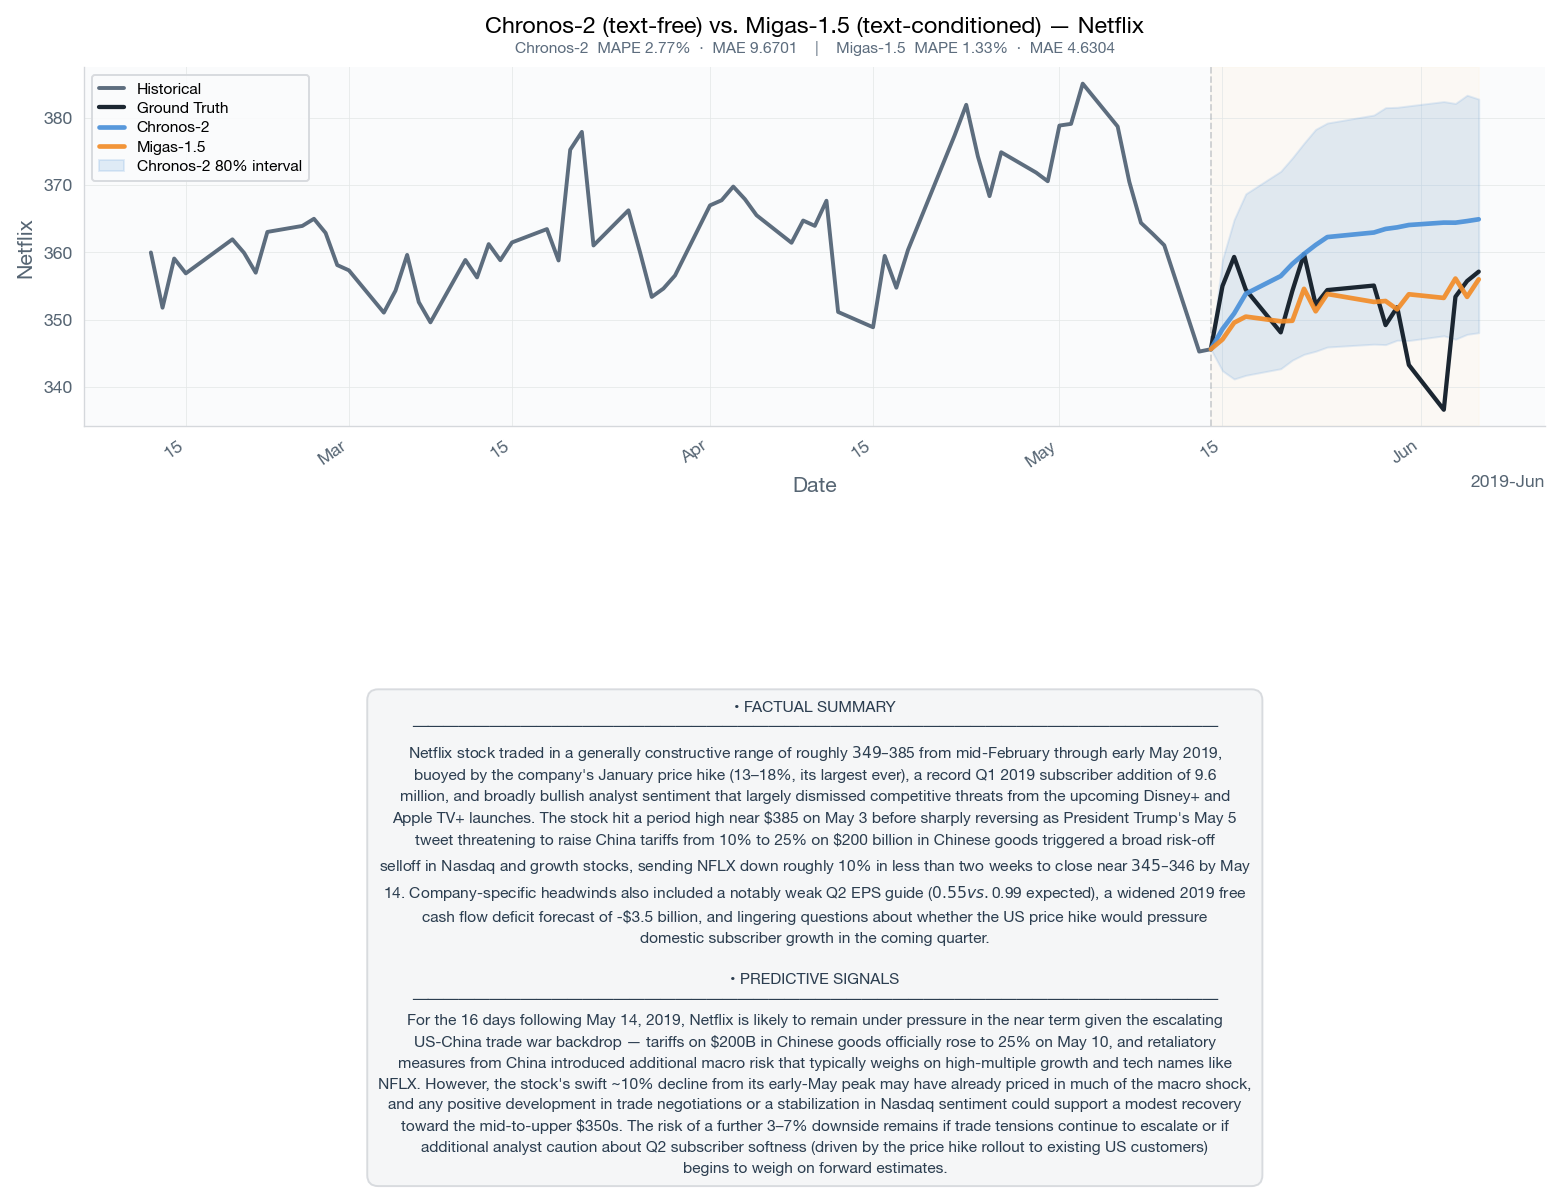

Chronos-2 slope  : +0.99719
Migas-1.5 slope  : +0.43033
Slope difference : -0.56686


In [72]:
t_ctx  = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1:]))
last_val = float(context_vals[-1])

fig, ax = plot_forecast_single(
    context_vals,
    gt_vals,
    {"Chronos-2": chronos_fc, "Migas-1.5": migas_fc},
    SEQ_LEN,
    PRED_LEN,
    title=f"Chronos-2 (text-free) vs. Migas-1.5 (text-conditioned) — {SERIES_NAME}",
    figsize=(11, 4),
    show_metrics=True,
    text_summary=summary,
    timestamps=full["t"].values,
)
# Add Chronos-2 uncertainty band (10th–90th percentile)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], chronos_lo]),
    np.concatenate([[last_val], chronos_hi]),
    alpha=0.15,
    color=COLORS["Chronos-2"],
    label="Chronos-2 80% interval",
    zorder=2,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
ax.set_ylabel(SERIES_NAME, color="#566573")
plt.show()

print(f"Chronos-2 slope  : {linear_slope(chronos_fc):+.5f}")
print(f"Migas-1.5 slope  : {linear_slope(migas_fc):+.5f}")
print(f"Slope difference : {linear_slope(migas_fc) - linear_slope(chronos_fc):+.5f}")

## 5. Counterfactual — Rewrite the Narrative

Here is the core idea behind Migas-1.5: **the numerical input is identical across all
runs below — only the text changes.**

We keep the **factual section** unchanged (what already happened doesn't change) and
replace only the **predictive signals** with a bullish or bearish outlook.
If the model truly integrates text with time series, the forecast should shift
in the direction of the new narrative.

If `LLM_API_KEY` is set, the predictive signals are generated by the LLM conditioned
on the factual context. Otherwise, hardcoded fallback narratives are used.

In [73]:
print("Factual section (unchanged across all scenarios):\n")
print(extract_factual(summary))
print("\nOriginal predictive section:\n")
print(extract_predictive(summary))

Factual section (unchanged across all scenarios):

FACTUAL SUMMARY:
Netflix stock traded in a generally constructive range of roughly $349–$385 from mid-February through early May 2019, buoyed by the company's January price hike (13–18%, its largest ever), a record Q1 2019 subscriber addition of 9.6 million, and broadly bullish analyst sentiment that largely dismissed competitive threats from the upcoming Disney+ and Apple TV+ launches. The stock hit a period high near $385 on May 3 before sharply reversing as President Trump's May 5 tweet threatening to raise China tariffs from 10% to 25% on $200 billion in Chinese goods triggered a broad risk-off selloff in Nasdaq and growth stocks, sending NFLX down roughly 10% in less than two weeks to close near $345–$346 by May 14. Company-specific headwinds also included a notably weak Q2 EPS guide ($0.55 vs. $0.99 expected), a widened 2019 free cash flow deficit forecast of -$3.5 billion, and lingering questions about whether the US price hike 

In [74]:
# Fallback narratives — used when no LLM key is available.  # <-- CHANGE ME if not using LLM
_bullish_fallback = dedent("""
    PREDICTIVE SIGNALS:
    The energy market is entering a strong upside regime: an unexpected cold snap has
    driven heating demand to multi-year highs, storage draws are accelerating well beyond
    seasonal norms, and LNG export capacity is running near full utilization. Supply
    disruptions from key production regions and a weaker dollar are compounding the
    tightness. The path of least resistance is sharply higher, with a rapid continuation
    move and further gains far more likely than any meaningful pullback over the forecast
    window.
""").strip()

_bearish_fallback = dedent("""
    PREDICTIVE SIGNALS:
    The energy market is entering a strong downside regime: a warmer-than-expected
    weather pattern has collapsed heating demand, storage injections are running above
    seasonal norms, and record domestic production is overwhelming any export-driven
    support. Demand destruction from high prices in prior months is now feeding back
    into oversupply, and risk appetite for commodity longs has deteriorated sharply.
    The highest-probability path over the forecast window is a rapid, sustained decline
    with little prospect of near-term recovery.
""").strip()

if LLM_API_KEY:
    _cf_prompt = (
        f"You are writing counterfactual PREDICTIVE SIGNALS sections for a Migas-1.5 "
        f"time series forecast of {SERIES_NAME}.\n\n"
        f"The factual context is:\n{extract_factual(summary)}\n\n"
        f"Write two short paragraphs (2-3 sentences each), each starting exactly with "
        f"'PREDICTIVE SIGNALS:' on its own line.\n"
        f"Paragraph 1 — EXTREME BULLISH: invent a plausible but strongly bullish scenario "
        f"(demand spike, supply shock, policy tailwind, etc.). Use relative terms only — "
        f"no absolute price targets.\n"
        f"Paragraph 2 — EXTREME BEARISH: invent a plausible but strongly bearish scenario "
        f"(demand collapse, supply glut, policy headwind, etc.). Use relative terms only.\n"
        f"Output ONLY the two paragraphs, nothing else."
    )
    print("Generating counterfactual narratives with LLM …")
    _cf_response = call_llm(
        _cf_prompt,
        provider=LLM_PROVIDER,
        api_key=LLM_API_KEY,
        base_url=LLM_BASE_URL,
        model=LLM_MODEL,
    )
    # Split on the second "PREDICTIVE SIGNALS:" marker
    _parts = _cf_response.split("PREDICTIVE SIGNALS:")
    if len(_parts) >= 3:
        bullish_predictive = ("PREDICTIVE SIGNALS:" + _parts[1]).strip()
        bearish_predictive = ("PREDICTIVE SIGNALS:" + _parts[2]).strip()
    else:
        # Fallback if the LLM didn't produce the expected structure
        bullish_predictive = _bullish_fallback
        bearish_predictive = _bearish_fallback
    print("Bullish:\n", bullish_predictive)
    print("\nBearish:\n", bearish_predictive)
else:
    print("No LLM key — using fallback counterfactual narratives.")
    bullish_predictive = _bullish_fallback
    bearish_predictive = _bearish_fallback

bullish_summary = splice_summary(summary, bullish_predictive)
bearish_summary = splice_summary(summary, bearish_predictive)

Generating counterfactual narratives with LLM …
Bullish:
 PREDICTIVE SIGNALS:
International expansion accelerates unexpectedly as Disney's delayed European rollout of Disney+ creates a 12–18 month window where Netflix captures incremental UCAN and EMEA subscribers at record rates, while simultaneous weakness in legacy cable pricing emboldens a wave of cord-cutting that overwhelms price-sensitivity concerns around the January hike. Margin expansion from pricing power and operating leverage compounds the narrative, sending sentiment into a pronounced recovery phase as investors re-rate the competitive moat and revise subscriber runway models sharply upward.

Bearish:
 PREDICTIVE SIGNALS:
The Trump tariff escalation metastasizes into a broader trade war that depresses consumer discretionary spending across income cohorts, while simultaneous content cost inflation driven by bidding wars against Disney+ and Apple TV+ compresses operating margins and forces Netflix to cut original programmin

In [75]:
bullish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=[bullish_summary]
)
bearish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=[bearish_summary]
)

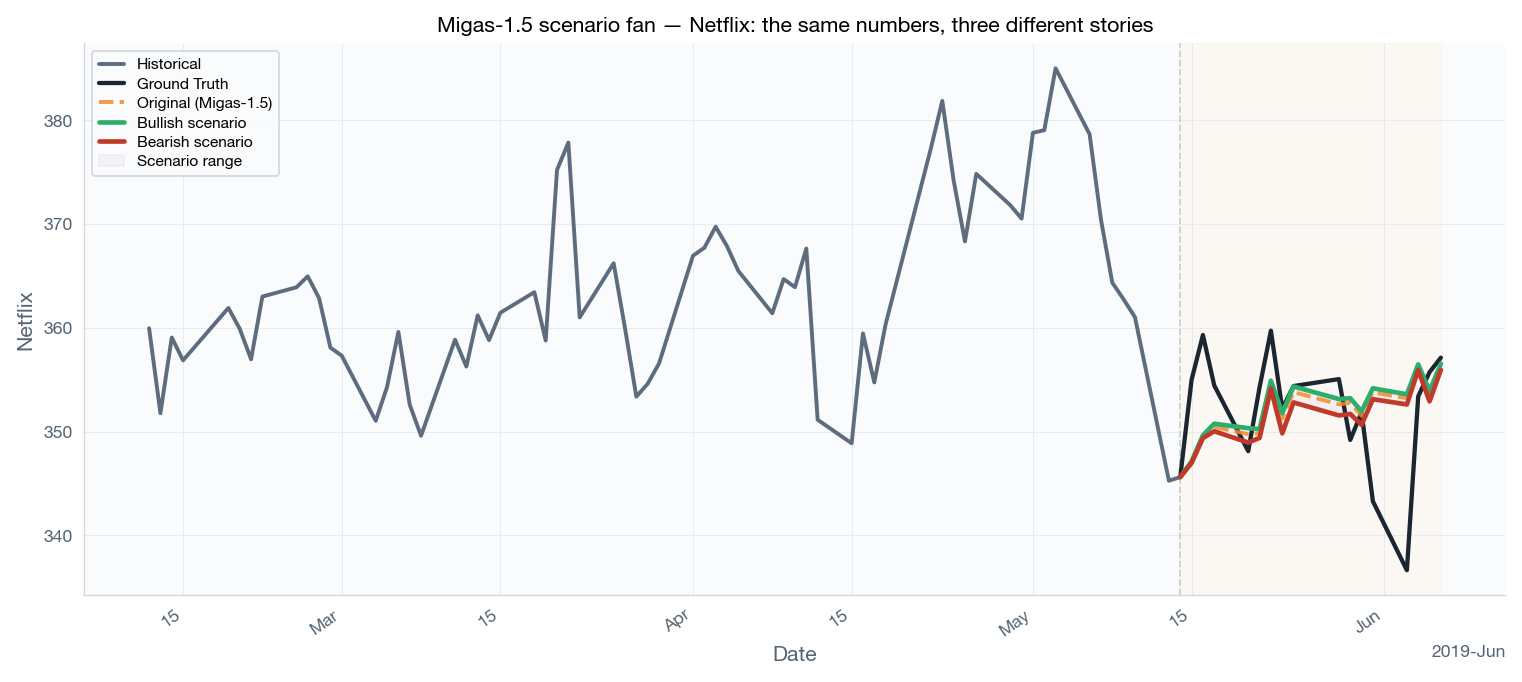

In [76]:
BULLISH_COLOR = "#2EAD6D"
BEARISH_COLOR = "#C0392B"

t_ctx  = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1:]))
last_val = float(context_vals[-1])

fig, ax = plt.subplots(figsize=(11, 5))
_draw_forecast_region(ax, SEQ_LEN, PRED_LEN, boundary=t_pred[0], boundary_end=t_pred[-1])

ax.plot(
    t_ctx,
    context_vals,
    color=COLORS["historical"],
    lw=2.0,
    label="Historical",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], gt_vals]),
    color=COLORS["ground_truth"],
    lw=2.2,
    label="Ground Truth",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], migas_fc]),
    color=COLORS["Migas-1.5"],
    lw=2.0,
    ls="--",
    alpha=0.85,
    label="Original (Migas-1.5)",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bullish_fc]),
    color=BULLISH_COLOR,
    lw=2.4,
    label="Bullish scenario",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    color=BEARISH_COLOR,
    lw=2.4,
    label="Bearish scenario",
    solid_capstyle="round",
)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    np.concatenate([[last_val], bullish_fc]),
    alpha=0.08,
    color="#9B8EC4",
    label="Scenario range",
)

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(35)
    lbl.set_ha("right")
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(SERIES_NAME, color="#566573")
ax.set_title(
    f"Migas-1.5 scenario fan — {SERIES_NAME}: the same numbers, three different stories",
    fontsize=11,
    fontweight=600,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

In [77]:
orig_slope = linear_slope(migas_fc)
bull_slope = linear_slope(bullish_fc)
bear_slope = linear_slope(bearish_fc)

rows = [
    {
        "Scenario": "Chronos-2 (no text)",
        "Slope": f"{linear_slope(chronos_fc):+.5f}",
        "Slope shift vs original": "—",
        "Trend score (↑)": f"{composite_trend_score(chronos_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Migas-1.5 original",
        "Slope": f"{orig_slope:+.5f}",
        "Slope shift vs original": "—",
        "Trend score (↑)": f"{composite_trend_score(migas_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Bullish",
        "Slope": f"{bull_slope:+.5f}",
        "Slope shift vs original": f"{bull_slope - orig_slope:+.5f}",
        "Trend score (↑)": f"{composite_trend_score(bullish_fc, 'up', context_vals):+.3f}",
    },
    {
        "Scenario": "Bearish",
        "Slope": f"{bear_slope:+.5f}",
        "Slope shift vs original": f"{bear_slope - orig_slope:+.5f}",
        "Trend score (↑)": f"{composite_trend_score(bearish_fc, 'up', context_vals):+.3f}",
    },
]
print(pd.DataFrame(rows).to_string(index=False))

           Scenario    Slope Slope shift vs original Trend score (↑)
Chronos-2 (no text) +0.99719                       —          +0.232
 Migas-1.5 original +0.43033                       —          +0.074
            Bullish +0.44840                +0.01807          +0.055
            Bearish +0.42945                -0.00088          +0.075


The table confirms what the plot shows: the bullish narrative steers the slope positive,
the bearish narrative pulls it negative — all with the same context window.
Compare the Chronos-2 row (no text) with Migas-1.5 to see the baseline text effect.

## What's next

- **Try your own data** — point `DATA_PATH` at any CSV with `t`, `y_t`, `split` columns.
- **Generate a fresh summary** — set your API key and re-run Section 3 for a summary
  grounded in real recent context.
- **Batch evaluation** — see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)
  for rolling-window evaluation with ground truth.